In [173]:
from patsy.user_util import test_LookupFactor
from skimage.filters.rank import threshold_percentile

from src import ttl
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd

In [174]:
base_data_path = '/Volumes/AhmedLab/princess/data/testers/timesynch_tests'

# from 2p
# ttl_path = f'{base_data_path}/TSeries_20251218-513_Cycle00001_VoltageRecording_001.csv'
ttl_path = '/Volumes/AhmedLab/princess/data/testers/timesynch_tests/TSeries_20251218-514/TSeries_20251218-514_Cycle00001_VoltageRecording_001.csv'
ttl_csv = ttl.read_csv(ttl_path)

# from Bonsai
# bonsai_path = f'{base_data_path}/202624_synchtest_time2026-02-04T16_00_21.csv'
bonsai_path = f'/Volumes/AhmedLab/princess/data/testers/timesynch_tests/202624_synchtest_time2026-02-04T16_02_22.csv'

In [175]:
print(ttl_csv)

In [176]:
np.floor(ttl_csv.mean(axis=0))

Time(ms)       30236.0
Scope              0.0
Side Camera        3.0
Opto               0.0
dtype: float64

In [177]:
def extract_relative_timestamps(data, threshold = 3):
    on_signals = data[data['Opto'] > threshold]
    first_signal = on_signals['Time(ms)'].iloc[0]

    timestamps = on_signals[on_signals['Time(ms)'].diff() > 2 * ttl.get_TTL_frame_period(data)]['Time(ms)']
    timestamps = np.concatenate([[first_signal], timestamps.to_numpy()])

    return timestamps

In [178]:
scope_timestamps_ttl = ttl.extract_2p_relative_timestamps(ttl_csv)
camera_timestamps_ttl = ttl.extract_camera_relative_timestamps(ttl_csv)
opto_timestamps_ttl = extract_relative_timestamps(ttl_csv) # only shows on times

In [179]:
print(max(ttl_csv['Time(ms)']))

60473.0


In [180]:
print(opto_timestamps_ttl)
print(scope_timestamps_ttl)

[  500.01 10500.27 20500.53 30500.79 40501.05 50501.31]
[2.000000e-02 6.643000e+01 1.327300e+02 1.990300e+02 2.653300e+02
 3.316300e+02 3.979400e+02 4.642400e+02 5.305400e+02 5.968400e+02
 6.631400e+02 7.294400e+02 7.958700e+02 8.621700e+02 9.284700e+02
 9.947700e+02 1.061070e+03 1.127370e+03 1.193670e+03 1.259970e+03
 1.326280e+03 1.392580e+03 1.458880e+03 1.525180e+03 1.591480e+03
 1.657780e+03 1.724080e+03 1.790380e+03 1.856690e+03 1.922990e+03
 1.989290e+03 2.055590e+03 2.121890e+03 2.188190e+03 2.254490e+03
 2.320790e+03 2.387100e+03 2.453400e+03 2.519700e+03 2.586000e+03
 2.652430e+03 2.718730e+03 2.785030e+03 2.851330e+03 2.917630e+03
 2.983940e+03 3.050240e+03 3.116540e+03 3.182840e+03 3.249140e+03
 3.315440e+03 3.381750e+03 3.448050e+03 3.514350e+03 3.580650e+03
 3.646950e+03 3.713250e+03 3.779560e+03 3.845860e+03 3.912160e+03
 3.978460e+03 4.044760e+03 4.111060e+03 4.177370e+03 4.243670e+03
 4.309970e+03 4.376270e+03 4.442570e+03 4.508880e+03 4.575180e+03
 4.641480e+03 4.7077

(0.0, 20600.53)

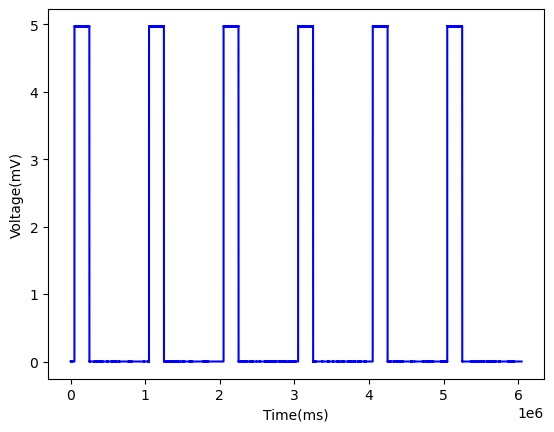

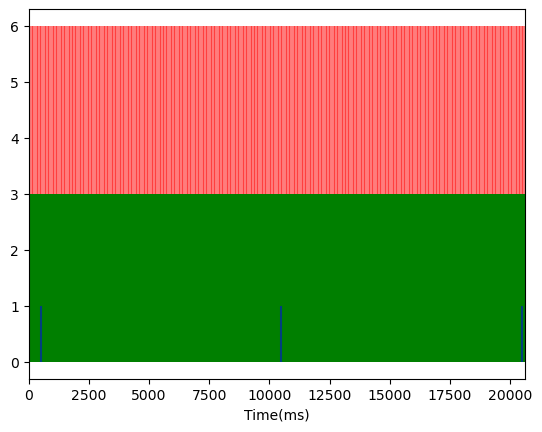

In [377]:
# plot all frame timestamps

# plt.plot(ttl_csv['Scope'], color='r')
# plt.plot(ttl_csv['Side Camera'], color='g')
plt.plot(ttl_csv['Opto'], color='b')
plt.xlabel('Time(ms)')
plt.ylabel('Voltage(mV)')
# plt.xlim(0, 200000)

plt.figure()
plt.vlines(scope_timestamps_ttl,0,6, colors='r', alpha=0.5)
plt.vlines(camera_timestamps_ttl,0,3, colors='g', alpha=0.5)
plt.vlines(opto_timestamps_ttl,0,1, colors='b', alpha=0.5)
plt.xlabel('Time(ms)')
plt.xlim(0,opto_timestamps_ttl[2]+100)

In [182]:

bonsai_csv = pd.read_csv(bonsai_path, header=None)

In [183]:
from datetime import datetime

In [184]:
bonsai_ts_arr = bonsai_csv[0].to_numpy()

In [185]:
print(bonsai_ts_arr)

['2026-02-04T16:02:23.0259968' '2026-02-04T16:02:23.0291712'
 '2026-02-04T16:02:23.0368000' ... '2026-02-04T16:03:22.4614400'
 '2026-02-04T16:03:22.4690688' '2026-02-04T16:03:22.4767104']


In [186]:
test = bonsai_ts_arr[0]
test = test[:-1]
print(test)
test2 = bonsai_ts_arr[1][:-1]

dt_test = datetime.strptime(test, '%Y-%m-%dT%H:%M:%S.%f')
dt_test2 = datetime.strptime(test2, '%Y-%m-%dT%H:%M:%S.%f')
print(dt_test, dt_test2)

diff = dt_test2 - dt_test # needs a date to subtract, won't work with just time

2026-02-04T16:02:23.025996
2026-02-04 16:02:23.025996 2026-02-04 16:02:23.029171


In [187]:
# loop over all times
bonsai_timestamps = []
for time in bonsai_ts_arr:
    shortened_time = time[:-1] # datetime can only handle 6 digits in the milliseconds

    # convert string to datetime format
    dt_object = datetime.strptime(shortened_time, '%Y-%m-%dT%H:%M:%S.%f')
    bonsai_timestamps.append(dt_object)

start_time = bonsai_timestamps[0]

# to calculate time relative to first frame
relative_bonsai_timestamps = []
bonsai_timestamp_diffs = []
for i, ts in enumerate(bonsai_timestamps):
    # if i == 0:
    #     # print(bonsai_timestamps[i])
    # #     relative_bonsai_timestamps.append(str(bonsai_timestamps[i]-start_time))
    #     relative_bonsai_timestamps.append(bonsai_timestamps[i]-start_time)
    relative_bonsai_timestamps.append((bonsai_timestamps[i]-start_time).total_seconds())
    bonsai_timestamp_diffs.append((bonsai_timestamps[i]-bonsai_timestamps[i-1]).total_seconds())
relative_bonsai_timestamps_ms = [x*1000 for x in relative_bonsai_timestamps]
# bonsai_timestamp_diffs = bonsai_timestamp_diffs*1000

Number of Bonsai timestamps: 7772, Number of Basler TTls: 7774


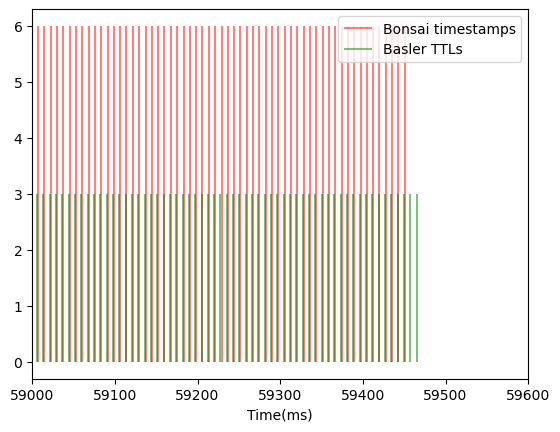

In [188]:
plt.vlines(relative_bonsai_timestamps_ms,0,6, colors='r', alpha=0.5, label = 'Bonsai timestamps')
plt.vlines(camera_timestamps_ttl,0,3, colors='g', alpha=0.5, label='Basler TTLs')
plt.xlabel('Time(ms)')
plt.xlim(59000,59600)
plt.legend()
print(f'Number of Bonsai timestamps: {len(relative_bonsai_timestamps)}, Number of Basler TTls: {len(camera_timestamps_ttl)}')

Text(0, 0.5, 'time difference (s)')

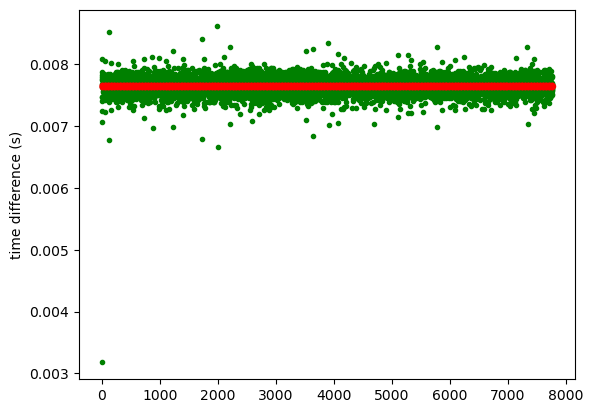

In [189]:
basler_ttl_diffs = [(camera_timestamps_ttl[i] - camera_timestamps_ttl[i-1])/1000 for i in range(1, len(camera_timestamps_ttl))]
plt.plot(bonsai_timestamp_diffs[1:], marker='.', linestyle='None', color='g')

plt.plot(basler_ttl_diffs, marker='.', linestyle='None', color='r', alpha=0.5)
plt.ylabel('time difference (s)')

In [216]:
import cv2
import numpy as np

video_path = f'{base_data_path}/202624_synchtest_side2026-02-04T16_00_21.avi'

In [245]:
video = cv2.VideoCapture(video_path)

old_frame = None
average_brightness = []



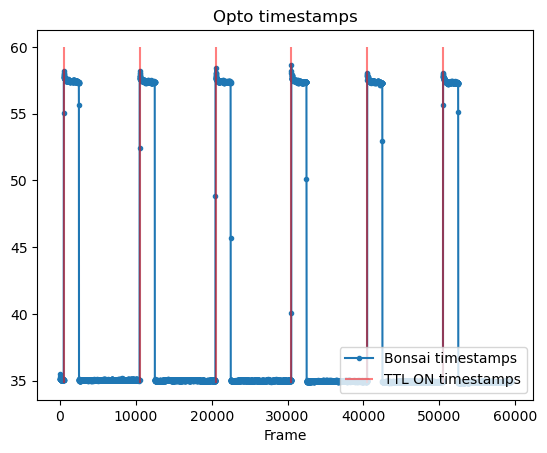

In [330]:
plt.plot(relative_bonsai_timestamps_ms, average_brightness, marker='.', label='Bonsai timestamps')
plt.vlines(opto_timestamps_ttl,min(average_brightness),60, colors='r', alpha=0.5, label='TTL ON timestamps')
# plt.plot(relative_bonsai_timestamps_ms, rolling_df, marker='.', label='Bonsai timestamps')
plt.xlabel('Frame')
plt.title('Opto timestamps')
plt.legend(loc='lower right')
# plt.ylim(57.5,59)

In [335]:
# how close in ms is ttl signal to
# opto_timestamps_ttl = [ms_0, ms_1, ...]

# find opto ons where the bonsai brightness is greatest
bright_change = np.diff(average_brightness)
# on_times = average_brightness.index(bright_change > 10).all()
# print(on_times)
on_times = []
on_frames = []
for i, val in enumerate(bright_change):
    if val > 10:
        brightens = (relative_bonsai_timestamps_ms[i] + relative_bonsai_timestamps_ms[i+1])/2
        brightens_frame = i
        on_times.append(relative_bonsai_timestamps_ms[i])
        on_frames.append(brightens_frame)
print(on_times)
print(opto_timestamps_ttl)
# plt.plot(bright_change, marker='.', linestyle='None', color='g')
print(on_times - opto_timestamps_ttl)

[484.8, 10484.596, 20484.34, 30491.802, 40491.623, 50491.456]
[  500.01 10500.27 20500.53 30500.79 40501.05 50501.31]
[-15.21  -15.674 -16.19   -8.988  -9.427  -9.854]


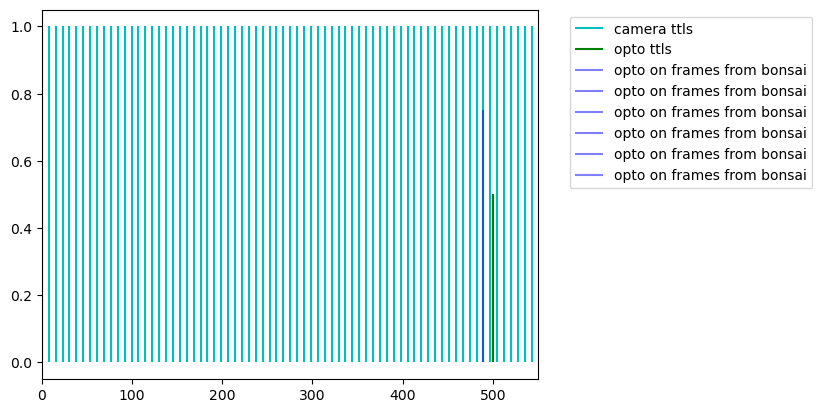

In [351]:
# what about frame index
on_frames # = [frame1, frame2, ...]
plt.vlines(camera_timestamps_ttl, color='c', ymin=0, ymax=1, label='camera ttls')
plt.vlines(opto_timestamps_ttl, color='g', ymin=0, ymax=0.5, label='opto ttls')
for i in on_frames:
    plt.vlines(camera_timestamps_ttl[i], color='b', ymin=0, ymax=1, alpha=0.5, label='opto on frames from bonsai')

plt.xlim(0,550)

In [280]:
}video_path = f'{base_data_path}/202624_synchtest_side2026-02-04T16_00_21.avi'
video = cv2.VideoCapture(video_path)

old_frame = None
frame_diffs = []
while True:
    ret, frame = video.read()
    if ret == True:
        if old_frame is not None:
            frame_difference = cv2.absdiff(frame, old_frame)
        old_frame = frame
        avg_change = np.mean(frame_difference)
        frame_diffs.append(avg_change)
    else:
        break

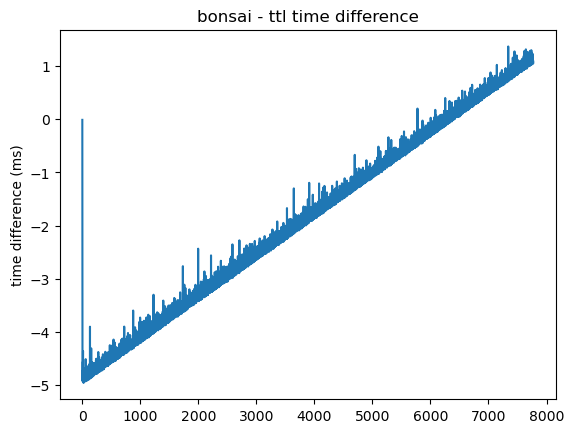

In [323]:
# frame differences between two sources
# does that drift over time

source_diffs = relative_bonsai_timestamps_ms-camera_timestamps_ttl[:-2]
plt.title('bonsai - ttl time difference')
plt.ylabel('time difference (ms)')
plt.plot(source_diffs)

In [352]:
# load ttl file into dataframe
ttl_df = pd.read_csv(ttl_path)
print(ttl_df.columns)
# pull camera timestamps
cam_ttl = ttl_df[' Input 2']
time = ttl_df['Time(ms)']

# binarize signal
threshold = 3.2  # Volts
binarized_cam = []
for signal in cam_ttl:
    if signal > threshold:
        binarized_cam.append(1)
    else:
        binarized_cam.append(0)

# get frame starts by finding +1 changes
diffs = [0] + np.diff(binarized_cam)

timestamps = []
for i, val in enumerate(diffs):
    if val == 1:
        timestamps.append(time[i])

print(len(timestamps))

Index(['Time(ms)', ' Input 1', ' Input 2', ' Input 3'], dtype='object')
7774


Text(0.5, 0, 'Time(ms)')

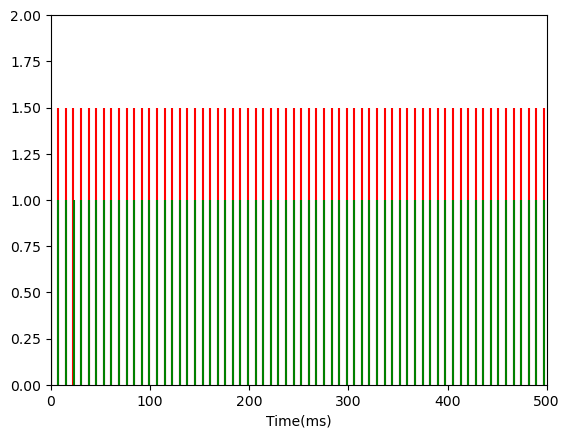

In [372]:
# plotting binarize frame starts against old method

plt.vlines(timestamps, ymin=0, ymax=1.5, colors='r')
plt.vlines(camera_timestamps_ttl, ymin=0, ymax=1, colors='g')
plt.xlim(0,500)
plt.ylim(0,2)
plt.xlabel('Time(ms)')

Text(0.5, 1.0, 'comparing timestamps from Carters method to Samas method')

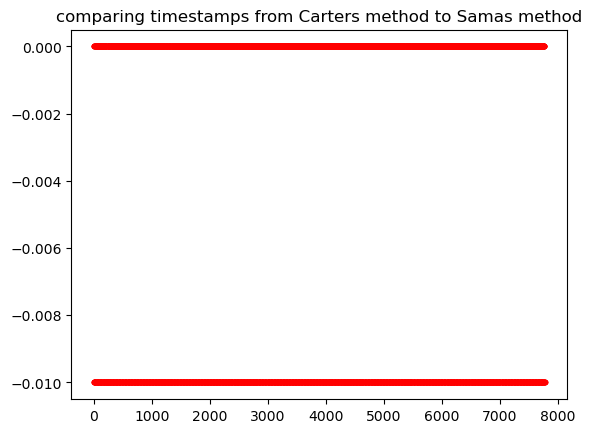

In [374]:
method_diff = [timestamps[i]-camera_timestamps_ttl[i] for i in range(len(timestamps))]
plt.plot(method_diff, linestyle='None', marker='.', color='r')
plt.title('comparing timestamps from Carters method to Samas method')